In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy.signal import butter, filtfilt

ECG signal length: 4438
PPG signal length: 4700


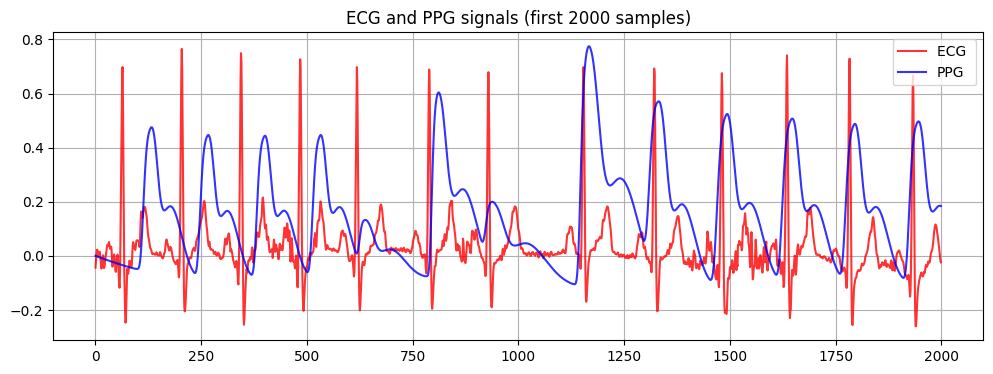

In [2]:
filename = '/content/AF_20251027_125032_120595.mat'
data = loadmat(filename, struct_as_record=False, squeeze_me=True)
signals = data['signals']

ecg_cell = signals.multileadECG

# Convert MATLAB cell (object array) to 1D numpy array
if isinstance(ecg_cell, np.ndarray) and ecg_cell.dtype == np.object_:
    ecg = np.array([float(x) for x in ecg_cell.flatten()])
else:
    ecg = np.asarray(ecg_cell).squeeze()
ppg = np.asarray(signals.PPG).squeeze()

print(f"ECG signal length: {len(ecg)}")  # Print ecg signal length
print(f"PPG signal length: {len(ppg)}")  # Print ppg signal length

plt.figure(figsize=(12, 4))
plt.plot(ecg[:2000], label='ECG ', color='r', alpha=0.8)
plt.plot(ppg[:2000], label='PPG', color='b', alpha=0.8)
plt.title("ECG and PPG signals (first 2000 samples)")
plt.legend()
plt.grid(True)
plt.show()

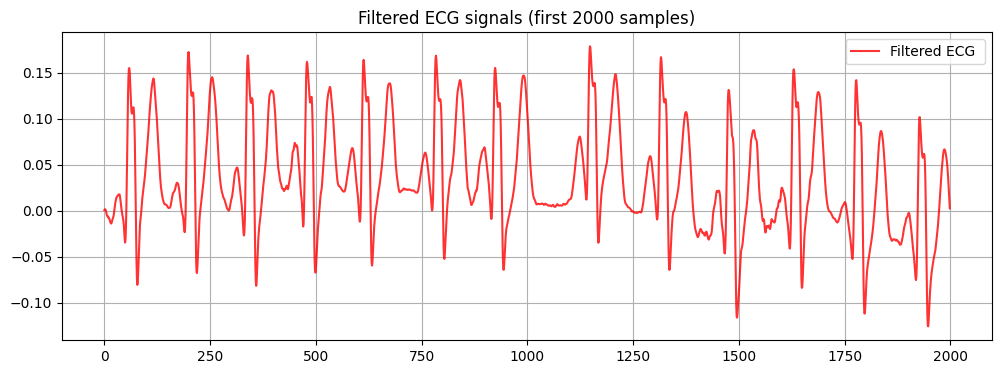

In [5]:
M = 20
h_lp = np.ones(M) / M
ecg_lp = np.convolve(ecg, h_lp, mode='same')
plt.figure(figsize=(12, 4))
plt.plot(ecg_lp[:2000], label='Filtered ECG ', color='r', alpha=0.8)
plt.title("Filtered ECG signals (first 2000 samples)")
plt.legend()
plt.grid(True)
plt.show()